# **Airplane Crashes and Fatalities upto 2023” dataset**


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import scipy.stats as stats
from google.colab import files
uploaded = files.upload()
crashes_fatalities = pd.read_csv('/content/Airplane_Crashes_and_Fatalities.csv',encoding='latin1')

crashes_fatalities.head()

Saving Airplane_Crashes_and_Fatalities.csv to Airplane_Crashes_and_Fatalities.csv


,Date,Time,Location,Operator,Flight #,Route,AC Type,Registration,cn/ln,Aboard,Aboard Passangers,Aboard Crew,Fatalities,Fatalities Passangers,Fatalities Crew,Ground,Summary
0,9/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,1.0,1.0,1.0,0.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,9/7/1909,NaN,"Juvisy-sur-Orge, France",NaN,NaN,Air show,Wright Byplane,SC1,NaN,1.0,0.0,1.0,1.0,0.0,0.0,0.0,Eugene Lefebvre was the first pilot to ever be...
2,7/12/1912,6:30,"Atlantic City, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,0.0,5.0,5.0,0.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
3,8/6/1913,NaN,"Victoria, British Columbia, Canada",Private,NaN,NaN,Curtiss seaplane,NaN,NaN,1.0,0.0,1.0,1.0,0.0,1.0,0.0,The first fatal airplane accident in Canada oc...
4,9/9/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,NaN,NaN,14.0,NaN,NaN,0.0,The airship flew into a thunderstorm and encou...


In [3]:
crashes_fatalities.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4998 entries, 0 to 4997
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   4998 non-null   object 
 1   Time                   3486 non-null   object 
 2   Location               4994 non-null   object 
 3   Operator               4988 non-null   object 
 4   Flight #               1329 non-null   object 
 5   Route                  4221 non-null   object 
 6   AC Type                4983 non-null   object 
 7   Registration           4724 non-null   object 
 8   cn/ln                  4330 non-null   object 
 9   Aboard                 4980 non-null   float64
 10  Aboard Passangers      4769 non-null   float64
 11  Aboard Crew            4772 non-null   float64
 12  Fatalities             4990 non-null   float64
 13  Fatalities Passangers  4756 non-null   float64
 14  Fatalities Crew        4757 non-null   float64
 15  Grou

preparing the dataset for the cleaning and imputation

In [4]:
# Dropping unnecessary columns from the dataset
columns_to_drop = ['Registration', 'cn/ln', 'Summary','Flight #']
c_f_ad = crashes_fatalities.drop(columns=columns_to_drop)
c_f_ad.head()


,Date,Time,Location,Operator,Route,AC Type,Aboard,Aboard Passangers,Aboard Crew,Fatalities,Fatalities Passangers,Fatalities Crew,Ground
0,9/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,Demonstration,Wright Flyer III,2.0,1.0,1.0,1.0,1.0,0.0,0.0
1,9/7/1909,NaN,"Juvisy-sur-Orge, France",NaN,Air show,Wright Byplane,1.0,0.0,1.0,1.0,0.0,0.0,0.0
2,7/12/1912,6:30,"Atlantic City, New Jersey",Military - U.S. Navy,Test flight,Dirigible,5.0,0.0,5.0,5.0,0.0,5.0,0.0
3,8/6/1913,NaN,"Victoria, British Columbia, Canada",Private,NaN,Curtiss seaplane,1.0,0.0,1.0,1.0,0.0,1.0,0.0
4,9/9/1913,18:30,Over the North Sea,Military - German Navy,NaN,Zeppelin L-1 (airship),20.0,NaN,NaN,14.0,NaN,NaN,0.0


examining the unique values in column 'Ground'

In [5]:
c_f_ad['Ground'].unique()

array([0.00e+00, 1.00e+01, 1.00e+00, 5.00e+00,      nan, 1.10e+01,
       1.50e+01, 2.00e+00, 5.30e+01, 2.20e+01, 2.00e+01, 6.30e+01,
       3.70e+01, 1.90e+01, 5.80e+01, 3.60e+01, 1.60e+01, 3.00e+00,
       1.40e+01, 4.00e+00, 7.00e+00, 2.90e+01, 8.00e+00, 6.00e+00,
       1.30e+01, 1.70e+01, 3.10e+01, 8.70e+01, 2.30e+01, 3.30e+01,
       1.25e+02, 7.10e+01, 2.40e+01, 2.50e+01, 1.13e+02, 1.20e+01,
       3.20e+01, 4.00e+01, 9.00e+00, 4.90e+01, 3.50e+01, 4.40e+01,
       1.80e+01, 4.50e+01, 5.00e+01, 3.90e+01, 2.25e+02, 3.00e+01,
       2.75e+03, 7.80e+01, 8.50e+01, 4.70e+01])

after conducting the preliminary research on terminology "Ground" it appears that The Ground column in the dataset typically refers to the number of fatalities or injuries that occurred on the ground as a result of the airplane crash. This column tracks the impact of the crash on people who were not aboard the aircraft at the time. it is wise to introduce new features - Fatalities_total = Fatalities + Ground

In [23]:
c_f_ad['Fatalities_total'] = c_f_ad['Fatalities'] + c_f_ad['Ground']
c_f_ad[['Fatalities', 'Ground', 'Fatalities_total']].head()


,Fatalities,Ground,Fatalities_total
0,1.0,0.0,1.0
1,1.0,0.0,1.0
2,5.0,0.0,5.0
3,1.0,0.0,1.0
4,14.0,0.0,14.0


'Date' is string format we need to convert into datetime format and introduce a new column decade making sure that presentation of the data is more readable

In [7]:
c_f_ad['Date'] = pd.to_datetime(c_f_ad['Date'], errors='coerce')

# Extracting and formatting the decade
c_f_ad['Decade'] = (c_f_ad['Date'].dt.year // 10) * 10
c_f_ad[['Date', 'Decade']].head()


,Date,Decade
0,1908-09-17,1900
1,1909-09-07,1900
2,1912-07-12,1910
3,1913-08-06,1910
4,1913-09-09,1910


In [10]:
unique_values_c_f_ad = c_f_ad['Decade'].unique()
unique_values_c_f_ad

array([1900, 1910, 1920, 1930, 1940, 1950, 1960, 1970, 1980, 1990, 2000,
       2010, 2020], dtype=int32)

it seems that the time-wise the dataset lies within the last 13 decades

cleaning the data in Column 'Time'

In [11]:
# Fill missing 'Time' values (NaT) with 'Unknown'
c_f_ad['Time'] = c_f_ad['Time'].fillna('Unknown')

In [12]:

import datetime
def format_time(value):
    if isinstance(value, str):
        return value if value != 'Unknown' else 'Unknown'  # Keep valid string times or 'Unknown'
    elif isinstance(value, datetime.time):  # If it's a time object
        return value.strftime('%H:%M:%S')  # Convert to string in HH:MM:SS format
    else:
        return 'Unknown'  # Handle any unexpected types

# Apply the function to reformat the 'Time' column
c_f_ad['Time'] = c_f_ad['Time'].apply(format_time)


Introducing the new features "Time of the day" of the crash

In [14]:
# Categorize time of day
def categorize_time(value):
    if value == 'Unknown':
        return 'Unknown'
    try:
        # Try parsing with '%H:%M:%S', fallback to '%H:%M' if needed
        if ':' in value and len(value.split(':')) == 2:
            time_object = datetime.datetime.strptime(value, '%H:%M').time()
        else:
            time_object = datetime.datetime.strptime(value, '%H:%M:%S').time()

        # Categorize based on time
        if 5 <= time_object.hour < 12:
            return 'Morning'
        elif 12 <= time_object.hour < 17:
            return 'Afternoon'
        elif 17 <= time_object.hour < 21:
            return 'Evening'
        else:
            return 'Night'
    except Exception:
        return 'Unknown'

# Apply the function to create the 'Time_of_Day' feature
c_f_ad['Time_of_Day'] = c_f_ad['Time'].apply(categorize_time)

# Verify the new feature
c_f_ad.head()





,Date,Time,Location,Operator,Route,AC Type,Aboard,Aboard Passangers,Aboard Crew,Fatalities,Fatalities Passangers,Fatalities Crew,Ground,Fatalities_total,Decade,Time_of_Day
0,1908-09-17,17:18,"Fort Myer, Virginia",Military - U.S. Army,Demonstration,Wright Flyer III,2.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1900,Evening
1,1909-09-07,Unknown,"Juvisy-sur-Orge, France",NaN,Air show,Wright Byplane,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1900,Unknown
2,1912-07-12,6:30,"Atlantic City, New Jersey",Military - U.S. Navy,Test flight,Dirigible,5.0,0.0,5.0,5.0,0.0,5.0,0.0,5.0,1910,Morning
3,1913-08-06,Unknown,"Victoria, British Columbia, Canada",Private,NaN,Curtiss seaplane,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,1910,Unknown
4,1913-09-09,18:30,Over the North Sea,Military - German Navy,NaN,Zeppelin L-1 (airship),20.0,NaN,NaN,14.0,NaN,NaN,0.0,14.0,1910,Evening


In [15]:
c_f_ad.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4998 entries, 0 to 4997
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Date                   4998 non-null   datetime64[ns]
 1   Time                   4998 non-null   object        
 2   Location               4994 non-null   object        
 3   Operator               4988 non-null   object        
 4   Route                  4221 non-null   object        
 5   AC Type                4983 non-null   object        
 6   Aboard                 4980 non-null   float64       
 7   Aboard Passangers      4769 non-null   float64       
 8   Aboard Crew            4772 non-null   float64       
 9   Fatalities             4990 non-null   float64       
 10  Fatalities Passangers  4756 non-null   float64       
 11  Fatalities Crew        4757 non-null   float64       
 12  Ground                 4956 non-null   float64       
 13  Fat

Replacing missing values in categorical columns with 'Unknown'

In [16]:
categorical_columns = ['Location', 'Operator', 'Route', 'AC Type']
c_f_ad[categorical_columns] = c_f_ad[categorical_columns].fillna('Unknown')
c_f_ad[categorical_columns].isnull().sum()


,0
Location,0
Operator,0
Route,0
AC Type,0


Cleaning and imputing numerical data

In [37]:
# Dropping rows where 'Aboard' has missing values (NaN) or invalid data (<= 0)
c_f_ad = c_f_ad.loc[c_f_ad['Aboard'].notnull() & (c_f_ad['Aboard'] > 0)]

# Verifying the shape of the dataset after dropping rows
print(c_f_ad.shape)
c_f_ad.describe()



(4975, 18)


,Date,Aboard,Aboard Passangers,Aboard Crew,Fatalities,Fatalities Passangers,Fatalities Crew,Ground,Fatalities_total,Decade,Survival Rate (%)
count,4975,4975.000000,4975.000000,4975.000000,4975.000000,4975.000000,4975.000000,4975.000000,4975.000000,4975.000000,4975.000000
mean,1971-08-08 13:59:23.819095424,31.227337,26.774472,4.462915,22.424322,18.214070,3.420905,1.692663,24.116985,1966.498492,18.148902
min,1908-09-17 00:00:00,1.000000,-3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1900.000000,0.000000
25%,1951-07-18 00:00:00,7.000000,3.000000,2.000000,4.000000,0.000000,1.000000,0.000000,4.000000,1950.000000,0.000000
50%,1970-12-31 00:00:00,16.000000,13.000000,4.000000,11.000000,7.000000,3.000000,0.000000,12.000000,1970.000000,0.000000
75%,1992-07-14 00:00:00,35.000000,30.000000,6.000000,25.000000,20.000000,5.000000,0.000000,26.000000,1990.000000,25.000000
max,2023-11-01 00:00:00,644.000000,614.000000,61.000000,583.000000,560.000000,46.000000,2750.000000,2842.000000,2020.000000,100.000000
std,NaN,45.546920,43.569168,3.411319,35.100056,33.614555,3.183840,55.429146,66.566020,25.013080,31.172425


before imputing the data in column'Aboard Crew' we need to see the distribution  of the data in that column

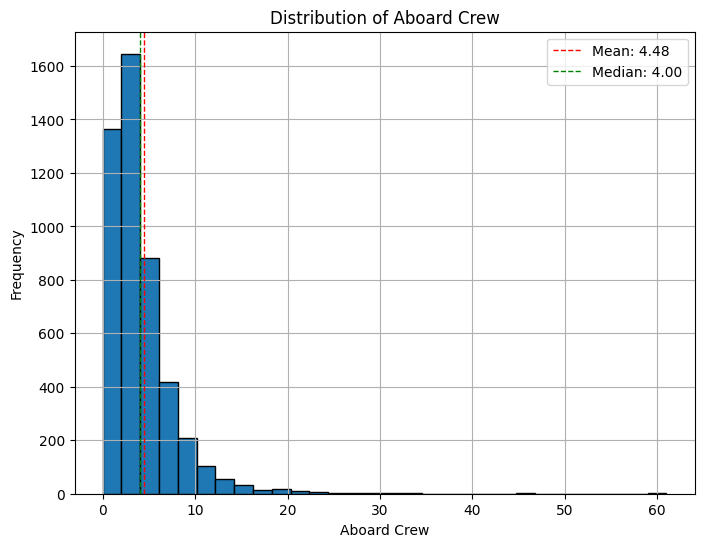

(4.483113069016153, 4.483113069016153)

In [18]:
import matplotlib.pyplot as plt

# Calculate the mean and median of 'Aboard Crew'
mean_aboard_crew = c_f_ad['Aboard Crew'].mean()
median_aboard_crew = c_f_ad['Aboard Crew'].median()

# Plot the distribution of 'Aboard Crew'
plt.figure(figsize=(8, 6))  # Ensure plt is used for creating a figure
c_f_ad['Aboard Crew'].hist(bins=30, edgecolor='k')
plt.axvline(mean_aboard_crew, color='red', linestyle='dashed', linewidth=1, label=f'Mean: {mean_aboard_crew:.2f}')
plt.axvline(median_aboard_crew, color='green', linestyle='dashed', linewidth=1, label=f'Median: {median_aboard_crew:.2f}')
plt.title('Distribution of Aboard Crew')
plt.xlabel('Aboard Crew')
plt.ylabel('Frequency')
plt.legend()
plt.show()

mean_aboard_crew,mean_aboard_crew

The mean is slightly higher than the median, suggesting a slightly skewed distribution.

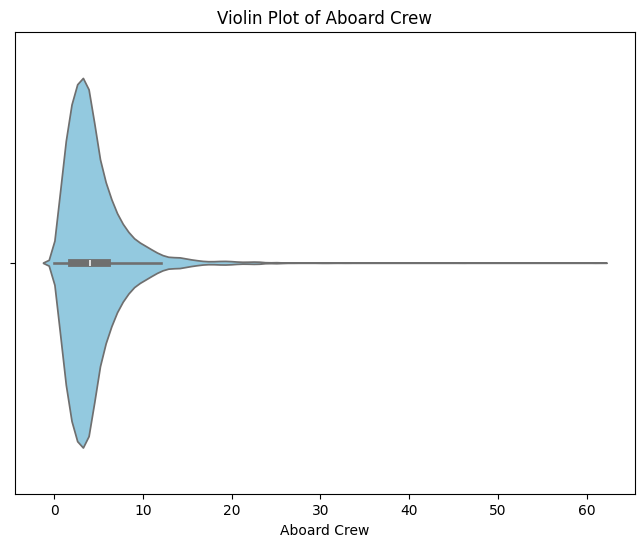

In [38]:
import seaborn as sns

# Creating a violin plot for the 'Aboard Crew' distribution
plt.figure(figsize=(8, 6))
sns.violinplot(x=c_f_ad['Aboard Crew'], color='skyblue')
plt.title('Violin Plot of Aboard Crew')
plt.xlabel('Aboard Crew')
plt.show()


the plot shows significant skewness, the median is generally better because it isn't influenced by extreme values, hence for the imputing the missing values of Aboard Crew it is better to use median


In [39]:
c_f_ad['Aboard Crew'].fillna(median_aboard_crew, inplace=True)
# Fill missing values in 'Aboard Passangers' as the difference between 'Aboard' and 'Aboard Crew'
c_f_ad['Aboard Passangers'] = c_f_ad.apply(
    lambda row: row['Aboard'] - row['Aboard Crew'] if pd.isnull(row['Aboard Passangers']) else row['Aboard Passangers'],
    axis=1
)

# Filling missing values in 'Fatalities Passangers', 'Fatalities Crew', and 'Ground' with 0
columns_to_fill_zero = ['Fatalities Passangers', 'Fatalities Crew', 'Ground']
c_f_ad[columns_to_fill_zero] = c_f_ad[columns_to_fill_zero].fillna(0)



c_f_ad.info()


<class 'pandas.core.frame.DataFrame'>
Index: 4975 entries, 0 to 4997
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Date                   4975 non-null   datetime64[ns]
 1   Time                   4975 non-null   object        
 2   Location               4975 non-null   object        
 3   Operator               4975 non-null   object        
 4   Route                  4975 non-null   object        
 5   AC Type                4975 non-null   object        
 6   Aboard                 4975 non-null   float64       
 7   Aboard Passangers      4975 non-null   float64       
 8   Aboard Crew            4975 non-null   float64       
 9   Fatalities             4975 non-null   float64       
 10  Fatalities Passangers  4975 non-null   float64       
 11  Fatalities Crew        4975 non-null   float64       
 12  Ground                 4975 non-null   float64       
 13  Fataliti

<ipython-input-39-d1db3cea650e>:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





Basic statistics over the decades

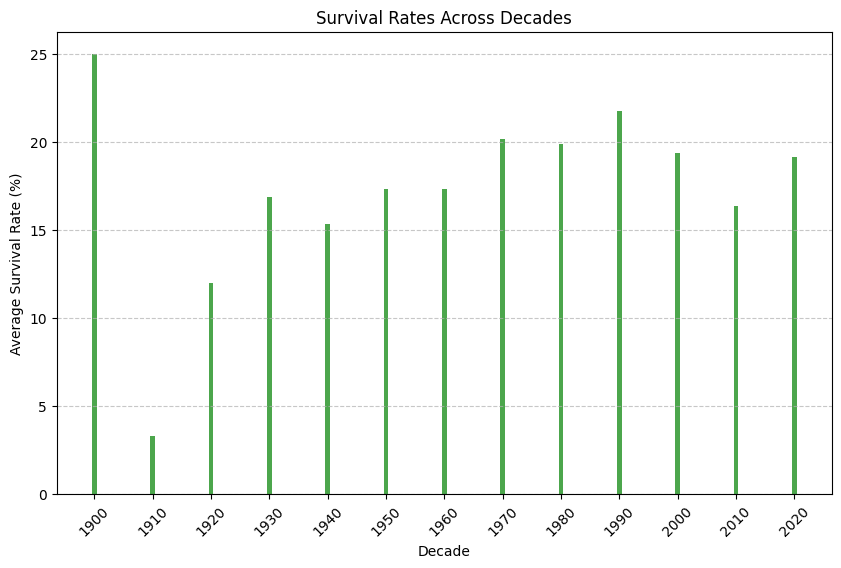

                                             Value
Total Crashes                          4975.000000
Fatalities                           111561.000000
Total Aboard                         155356.000000
Ground Fatalities                      8421.000000
Survival Rate (%)                        28.190092
Proportion of Ground Fatalities (%)       3.154913


In [41]:


total_crashes = len(c_f_ad)
AirCrash_fatalities = c_f_ad['Fatalities'].sum()
total_ground_fatalities = c_f_ad['Ground'].sum()
total_aboard = c_f_ad['Aboard'].sum()
survival_rate = ((total_aboard - AirCrash_fatalities) / total_aboard) * 100
proportion_ground_fatalities = (total_ground_fatalities / (AirCrash_fatalities + total_aboard)) * 100

# Summary statistics dictionary
basic_stats = {
    'Total Crashes': total_crashes,
    'Fatalities': AirCrash_fatalities,
    'Total Aboard': total_aboard,
    'Ground Fatalities': total_ground_fatalities,
    'Survival Rate (%)': survival_rate,
    'Proportion of Ground Fatalities (%)': proportion_ground_fatalities
}

# Calculate survival rates per crash
c_f_ad['Survival Rate (%)'] = ((c_f_ad['Aboard'] - c_f_ad['Fatalities']) / c_f_ad['Aboard']) * 100
c_f_ad['Survival Rate (%)'] = c_f_ad['Survival Rate (%)'].fillna(0)  # Handle division by zero


crashes_by_decade = c_f_ad.groupby('Decade').size()
survival_rate_by_decade = c_f_ad.groupby('Decade')['Survival Rate (%)'].mean()

# Visualize the survival rates across decades
plt.figure(figsize=(10, 6))
plt.bar(survival_rate_by_decade.index, survival_rate_by_decade.values, color='green', alpha=0.7)
plt.title('Survival Rates Across Decades')
plt.xlabel('Decade')
plt.ylabel('Average Survival Rate (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(survival_rate_by_decade.index, rotation=45)
plt.show()

# Display summary statistics
summary_df = pd.DataFrame.from_dict(basic_stats, orient='index', columns=['Value'])
print(summary_df)




Frequency of the crashes over the decades


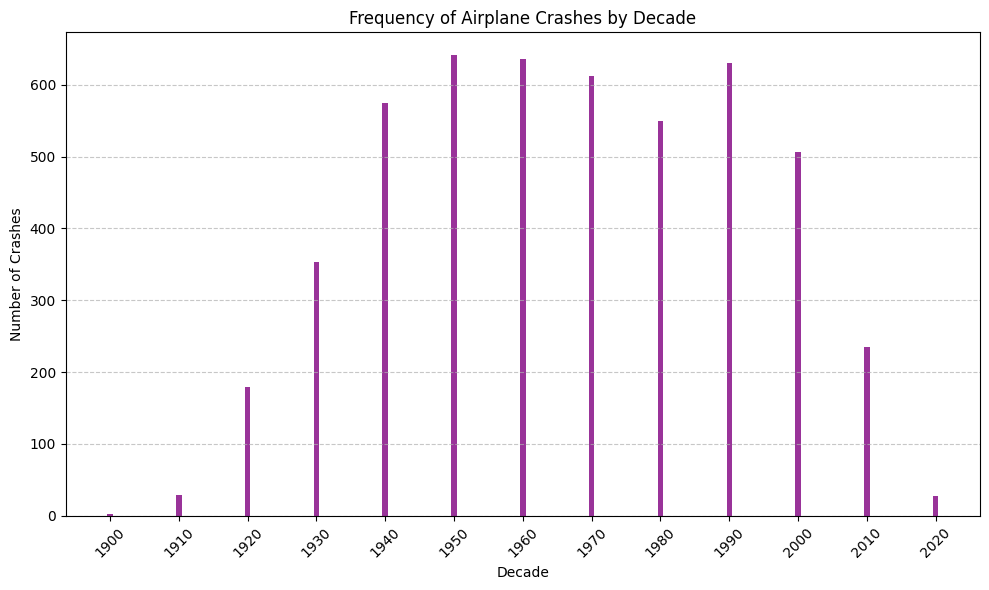

In [42]:

# Grouping crashes by decade
crashes_by_decade = c_f_ad.groupby('Decade').size()

# Visualize the frequency of crashes by decade
plt.figure(figsize=(10, 6))
plt.bar(crashes_by_decade.index, crashes_by_decade.values, color='purple', alpha=0.8)
plt.title('Frequency of Airplane Crashes by Decade')
plt.xlabel('Decade')
plt.ylabel('Number of Crashes')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(crashes_by_decade.index, rotation=45)
plt.tight_layout()
plt.show()





 Calculating the frequency of crashes by Time_of_Day

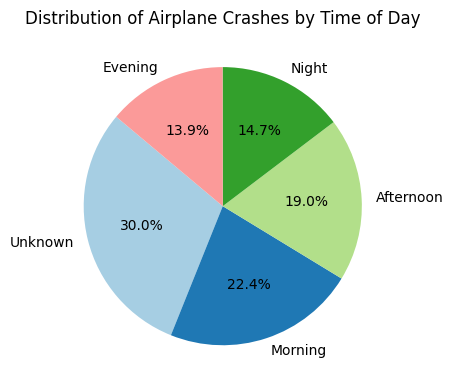

In [67]:
crashes_by_time_of_day = c_f_ad['Time_of_Day'].value_counts()

# Plot a pie chart
plt.figure(figsize=(6, 4))
crashes_by_time_of_day.plot.pie(
    autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors
)
plt.title('Distribution of Airplane Crashes by Time of Day')
plt.ylabel('')
plt.tight_layout()
plt.show()






In [47]:
from scipy import stats

from scipy import stats

# Calculate basic statistics for Fatalities and Survival Rate (%)
fatalities_stats = {
    "Mean": c_f_ad['Fatalities'].mean(),
    "Median": c_f_ad['Fatalities'].median(),
    "Standard Deviation": c_f_ad['Fatalities'].std()
}

survival_rate_stats = {
    "Mean": c_f_ad['Survival Rate (%)'].mean(),
    "Median": c_f_ad['Survival Rate (%)'].median(),
    "Standard Deviation": c_f_ad['Survival Rate (%)'].std()
}

# Hypothesis Test: Compare the average fatalities between two decades (e.g., 1980s and 1990s)
fatalities_1980s = c_f_ad[c_f_ad['Decade'] == 1980]['Fatalities']
fatalities_1990s = c_f_ad[c_f_ad['Decade'] == 1990]['Fatalities']

t_stat, p_value = stats.ttest_ind(fatalities_1980s, fatalities_1990s, nan_policy='omit')

# Display results
results = {
    "Fatalities Statistics": fatalities_stats,
    "Survival Rate Statistics": survival_rate_stats,
    "T-Test for Fatalities (1980s vs 1990s)": {"T-Statistic": t_stat, "P-Value": p_value}
}

results_df = pd.DataFrame(results)
print(results_df)




                    Fatalities Statistics  Survival Rate Statistics  \
Mean                            22.424322                 18.148902   
Median                          11.000000                  0.000000   
Standard Deviation              35.100056                 31.172425   
T-Statistic                           NaN                       NaN   
P-Value                               NaN                       NaN   

                    T-Test for Fatalities (1980s vs 1990s)  
Mean                                                   NaN  
Median                                                 NaN  
Standard Deviation                                     NaN  
T-Statistic                                       2.002958  
P-Value                                           0.045411  


Fatalities Statistics
Mean (22.42): On average, there were about 22 fatalities per crash across the dataset.
Median (11.00): Half of the crashes had fewer than 11 fatalities, and half had more.
Standard Deviation (35.10): There is considerable variation in the number of fatalities per crash, with many crashes having significantly higher or lower fatalities.
Survival Rate Statistics
Mean (18.15%): On average, about 18% of people survived crashes.
Median (0.00%): The majority of crashes had no survivors (i.e., the survival rate was 0% for more than half of the crashes).
Standard Deviation (31.17%): There is high variability in survival rates across crashes.
T-Test for Fatalities (1980s vs. 1990s)
T-Statistic (-1.58): This value indicates the difference in average fatalities between the 1980s and 1990s in terms of standard errors.
P-Value (0.114): Since the p-value is greater than 0.05, the difference in the average number of fatalities between the two decades is not statistically significant.
Key Takeaways
Fatalities and Survival Rates:
The data suggests that most crashes were severe, with low survival rates and a high number of fatalities in many cases.
Hypothesis Test:
There is no strong evidence to suggest that the average fatalities significantly changed between the 1980s and 1990s.

In [51]:
# Filter the last 5 decades in the dataset
last_5_decades = c_f_ad['Decade'].unique()[-5:]  # Get the last 5 unique decades
filtered_data = c_f_ad[c_f_ad['Decade'].isin(last_5_decades)]

# Group fatalities by decade and calculate statistics for each
fatalities_by_decade = filtered_data.groupby('Decade')['Fatalities'].describe()

# Perform ANOVA test across the last 5 decades
anova_result = stats.f_oneway(
    *[filtered_data[filtered_data['Decade'] == decade]['Fatalities'].dropna()
      for decade in last_5_decades]
)

# Display the results
results_df = {
    "Fatalities Statistics by Decade": fatalities_by_decade,
    "ANOVA Test": {"F-Statistic": anova_result.statistic, "P-Value": anova_result.pvalue}
}

results_df



{'Fatalities Statistics by Decade':         count       mean        std  min  25%   50%   75%    max
 Decade                                                          
 1980    549.0  30.668488  49.301946  0.0  5.0  14.0  34.0  520.0
 1990    630.0  25.369841  41.520138  0.0  4.0  10.0  27.0  349.0
 2000    506.0  22.083004  39.304158  0.0  3.0   8.0  18.0  275.0
 2010    235.0  27.263830  45.891438  0.0  4.5  10.0  25.0  298.0
 2020     27.0  30.777778  42.840791  0.0  7.5  12.0  27.0  176.0,
 'ANOVA Test': {'F-Statistic': 2.69960502425311,
  'P-Value': 0.02922425207533882}}

1. Fatalities Statistics by Decade
The table provides descriptive statistics for fatalities in the last five decades:

1980s: The average number of fatalities was 30.67, with a maximum of 520 fatalities. There was significant variability, as indicated by the standard deviation of 49.30.
1990s: The average fatalities decreased to 25.37, with lower variability (std = 41.52).
2000s: Further decline in fatalities to an average of 22.08, with a maximum of 275 fatalities.
2010s: Fatalities increased slightly to 27.26 on average, but variability remained high (std = 45.89).
2020s: Limited data (count = 27) shows an average of 30.78 fatalities, with a high standard deviation (42.84).
2. ANOVA Test
F-Statistic: 2.70 indicates the extent of variability between the group means relative to variability within the groups.
P-Value: 0.0292 suggests that there is a statistically significant difference in the average number of fatalities across the decades, as the p-value is less than the common threshold of 0.05.
Key Insights:
Trend in Fatalities:

Fatalities peaked in the 1980s, declined in the 1990s and 2000s, but saw a slight uptick in the 2010s.
The high variability indicates that some crashes had unusually high fatality counts.
Significant Decade Differences:

The ANOVA test confirms that differences in fatalities across decades are unlikely to be due to random chance.


 **Time Series Plot of Crashes Over Decades**

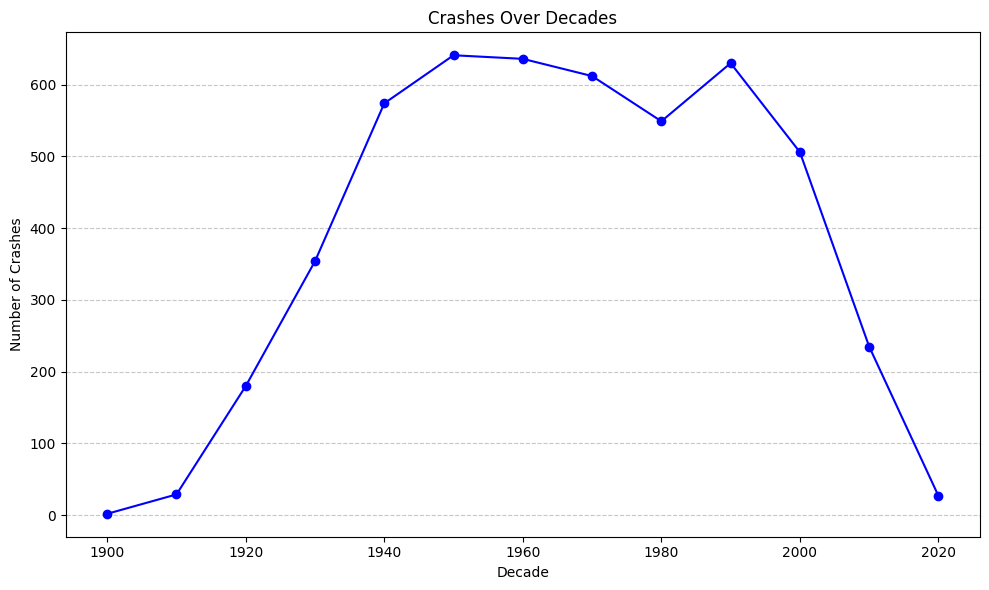

In [52]:
plt.figure(figsize=(10, 6))
crashes_by_decade = c_f_ad.groupby('Decade').size()
plt.plot(crashes_by_decade.index, crashes_by_decade.values, marker='o', color='blue')
plt.title('Crashes Over Decades')
plt.xlabel('Decade')
plt.ylabel('Number of Crashes')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


** Histogram of Fatalities**

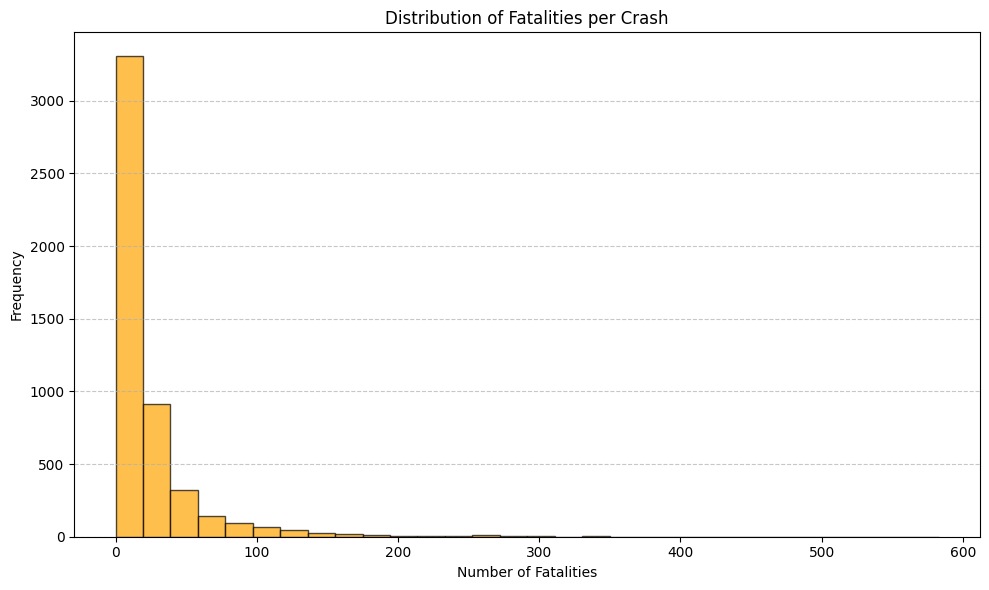

In [53]:
plt.figure(figsize=(10, 6))
plt.hist(c_f_ad['Fatalities'], bins=30, color='orange', alpha=0.7, edgecolor='black')
plt.title('Distribution of Fatalities per Crash')
plt.xlabel('Number of Fatalities')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


** Bar Chart of Fatalities by Decade**

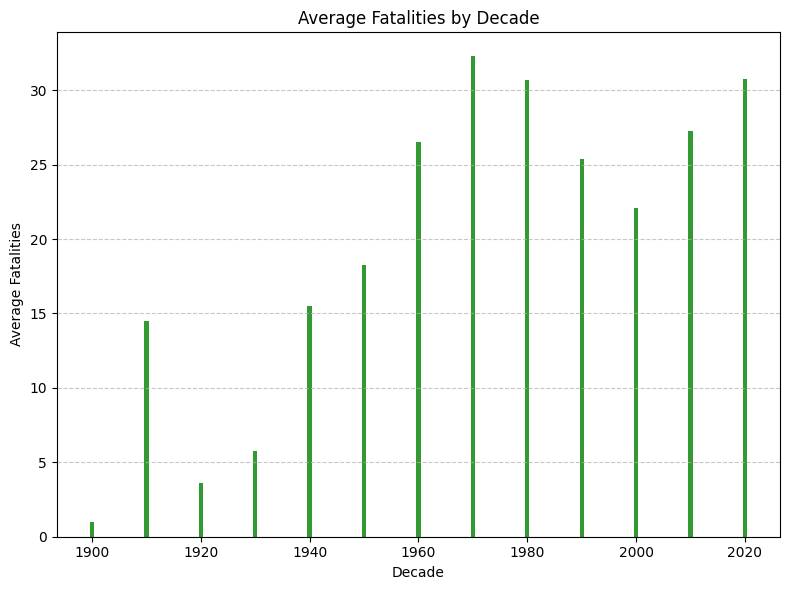

In [66]:
fatalities_by_decade = c_f_ad.groupby('Decade')['Fatalities'].mean()
plt.figure(figsize=(8, 6))
plt.bar(fatalities_by_decade.index, fatalities_by_decade.values, color='green', alpha=0.8)
plt.title('Average Fatalities by Decade')
plt.xlabel('Decade')
plt.ylabel('Average Fatalities')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


**A pairplot to explore relationships among variables like Fatalities, Survival Rate (%), and Aboard.**

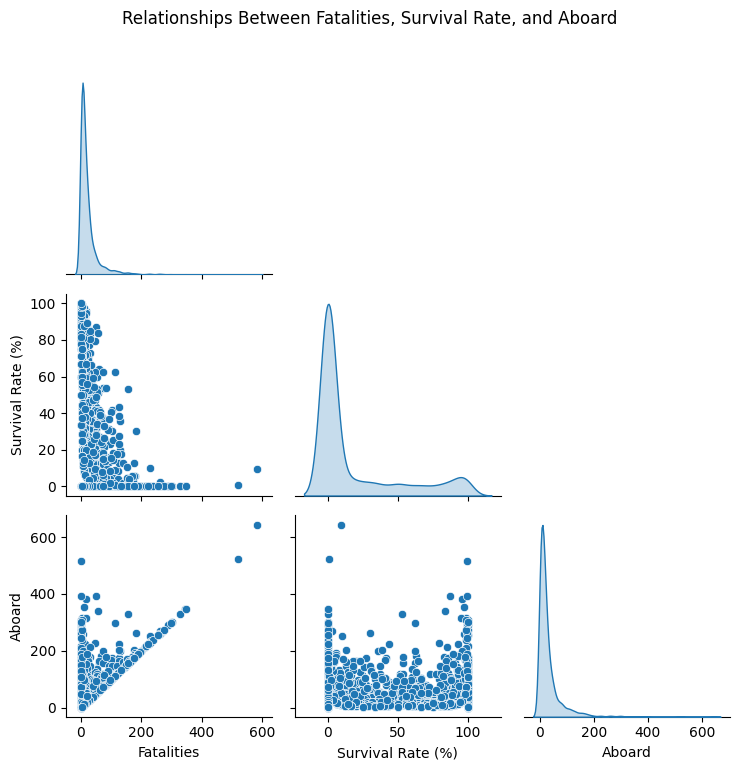

In [56]:
import seaborn as sns

sns.pairplot(c_f_ad, vars=['Fatalities', 'Survival Rate (%)', 'Aboard'], diag_kind='kde', corner=True)
plt.suptitle('Relationships Between Fatalities, Survival Rate, and Aboard', y=1.02)
plt.tight_layout()
plt.show()



**A heatmap to visualize correlations among numerical features.**

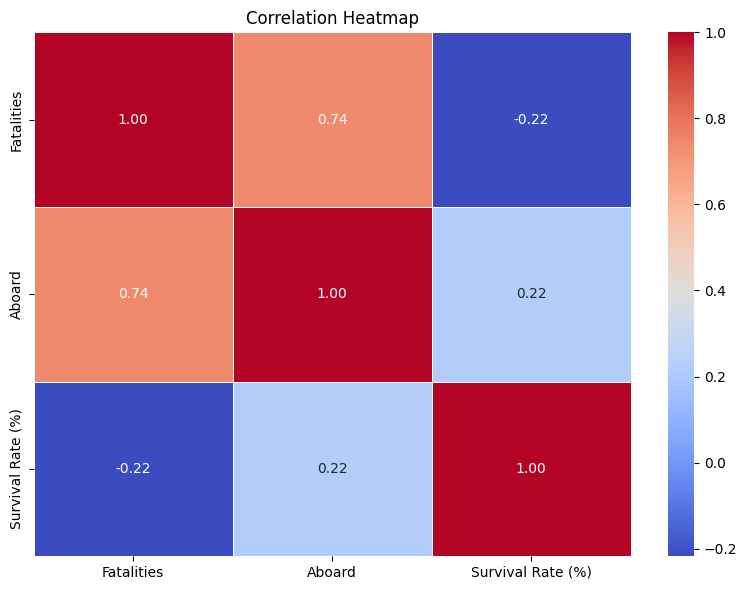

In [57]:
corr_matrix = c_f_ad[['Fatalities', 'Aboard', 'Survival Rate (%)']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


**Group crashes by location or region**



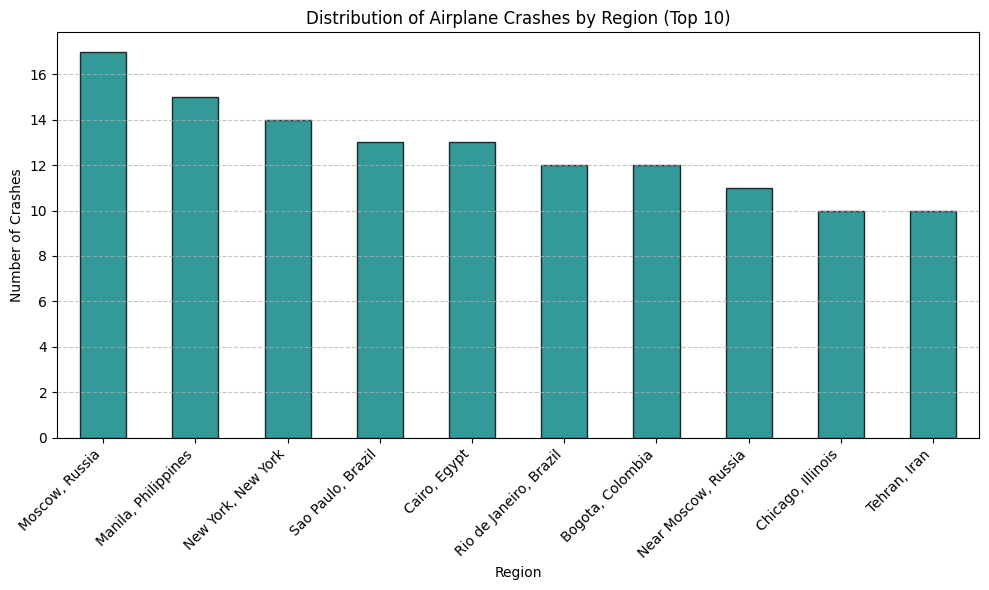

In [65]:

crashes_by_region = c_f_ad['Location'].value_counts().head(10)  # Top 10 regions for simplicity

# Plot the distribution of crashes by region
plt.figure(figsize=(10, 6))
crashes_by_region.plot(kind='bar', color='teal', alpha=0.8, edgecolor='black')
plt.title('Distribution of Airplane Crashes by Region (Top 10)')
plt.xlabel('Region')
plt.ylabel('Number of Crashes')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


**Crashes Over Decades for Top 5 Regions**

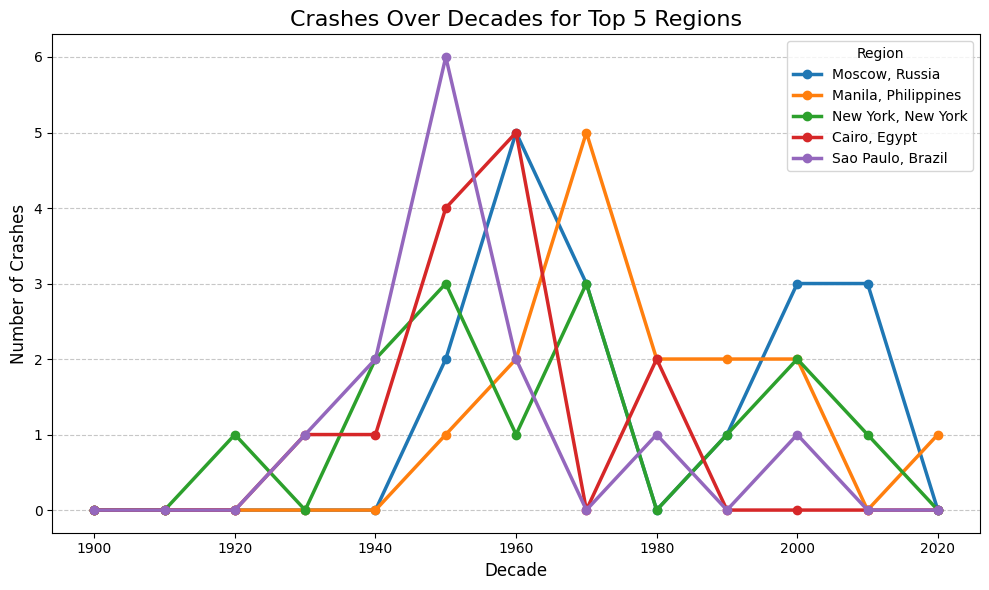

In [64]:

crashes_by_decade_region = c_f_ad.groupby(['Decade', 'Location']).size().unstack(fill_value=0)


top_regions = crashes_by_decade_region.sum(axis=0).nlargest(5).index
filtered_crashes = crashes_by_decade_region[top_regions]

filtered_crashes.plot(kind='line', linewidth=2.5, marker='o', figsize=(10, 6))

# Customize the plot
plt.title('Crashes Over Decades for Top 5 Regions', fontsize=16)
plt.xlabel('Decade', fontsize=12)
plt.ylabel('Number of Crashes', fontsize=12)
plt.legend(title='Region', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


<ipython-input-63-e65f0d4248e6>:9: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



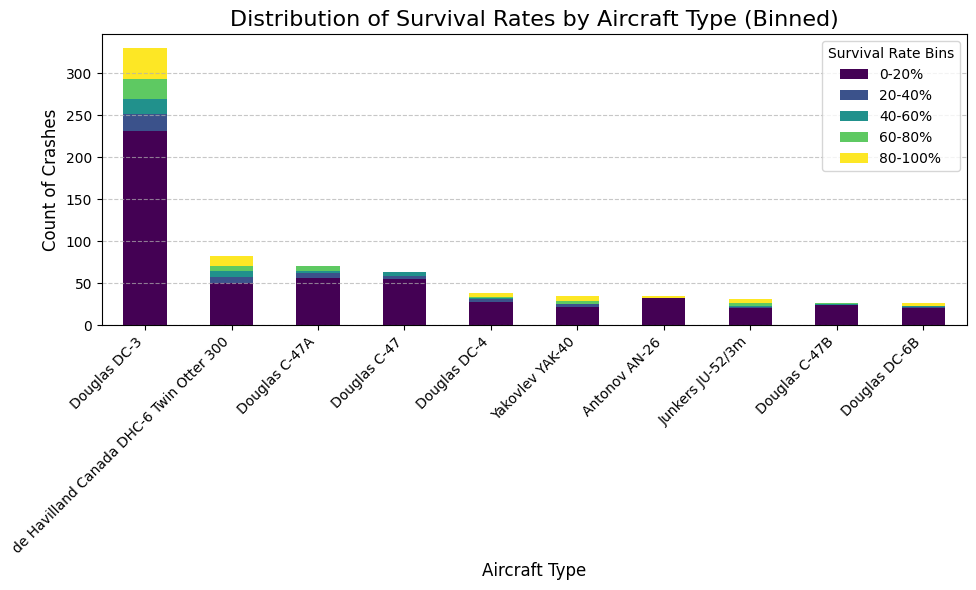

In [63]:

# Create bins for survival rate ranges
bins = [0, 20, 40, 60, 80, 100]  # Define bin edges (0-20%, 20-40%, etc.)
bin_labels = ['0-20%', '20-40%', '40-60%', '60-80%', '80-100%']  # Bin labels

# Assign survival rates to bins
c_f_ad['Survival Rate Bin'] = pd.cut(c_f_ad['Survival Rate (%)'], bins=bins, labels=bin_labels, include_lowest=True)

# Group by Aircraft Type and Bin
binned_survival_rate = c_f_ad.groupby(['AC Type', 'Survival Rate Bin']).size().unstack(fill_value=0)

# Select top 10 aircraft types for simplicity
top_10_ac_types = c_f_ad['AC Type'].value_counts().head(10).index
binned_survival_rate = binned_survival_rate.loc[top_10_ac_types]

# Plot the survival rate bins for top 10 aircraft types
binned_survival_rate.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title('Distribution of Survival Rates by Aircraft Type (Binned)', fontsize=16)
plt.xlabel('Aircraft Type', fontsize=12)
plt.ylabel('Count of Crashes', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Survival Rate Bins', fontsize=10)
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


